# Rabi Oscillations in a Driven Two-Level System

**Goal:**
Simulate the rabi oscillations of a two-level quantum system driven by a resonant pulse duration to logical quantum gates. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector, Operator
from scipy.linalg import expm
from IPython.display import display, clear_output
import time

import qiskit

print("All imports successful")

All imports successful


First, we need to determine the hamiltonian of a two level system. With no field, the hamiltonian is usually described by:

$$
H_0 = \frac{\hbar \omega_0}{2} \sigma_z
=
\begin{pmatrix}
\frac{\hbar \omega_0}{2} & 0 \\
0 & -\frac{\hbar \omega_0}{2}
\end{pmatrix}
$$

where omega is the angular frequency corresponding to the energy difference between the two quantum states.

You can find omega by doing:
$$\frac{E_1 - E_0}{\hbar}$$



In [3]:
hbar = 1.054571817 * (10 ** -34)
E0 = 0.0 #ground state energy
E1 = 1 * (10 ** -24) #excited state energy
omega_0 = (E1 - E0)/hbar

sigma_z = np.array([[1,0],[0,-1]], dtype=complex)

ket0 = Statevector.from_label('0')
ket1 = Statevector.from_label('1')

H0 = ((hbar * omega_0)/2) * sigma_z

print(H0)

[[ 5.e-25+0.j  0.e+00+0.j]
 [ 0.e+00+0.j -5.e-25+0.j]]


Overtime, the Hamiltonian with a driving force is described by: 
$$
H(t) = H_0 + H_\text{int}(t)
= \frac{\hbar \omega_0}{2} \sigma_z + \hbar \Omega \sigma_x
=
\begin{pmatrix}
\frac{\hbar \omega_0}{2} & \hbar \Omega \\
\hbar \Omega & -\frac{\hbar \omega_0}{2}
\end{pmatrix}
$$

Where Omega is the Rabi frequency. You calculate the Rabi frequency by doing:

$$
\Omega = \frac{d * E}{\hbar}
$$

where d is the dipole moment and E is the field strength

From the schrodinger equation, you get that: 
$$
|\psi(t)\rangle = e^{-i H t / \hbar} |\psi(0)\rangle
$$

so the unitary evolution operator is:

$$
U(t) = e^{- \frac{i H t}{\hbar}}
$$


Graph of oscillation:

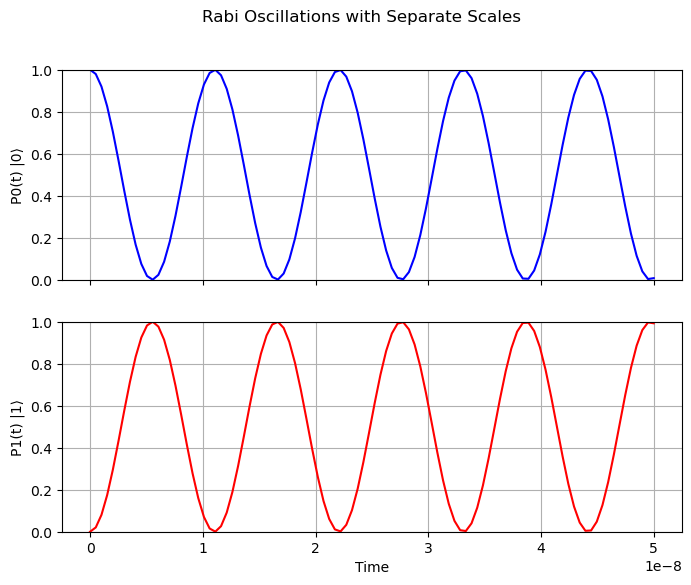

In [14]:
d = 3 * (10 ** -29)
E = 10 ** 3
Omega = d * E / hbar
omega = omega_0
sigma_x = np.array([[0,1],[1,0]], dtype=complex)

psi0 = Statevector.from_label('0') #initial state

t_max = 5 * (10 ** -8)
num_points = 100
times = np.linspace(0, t_max, num_points)
dt = times[1] - times[0]

psi_t = psi0.copy()

P0 = []
P1 = []

for t in times:
    H_t = hbar * Omega * sigma_x #simplfied the hamiltonian to get a nicer function despite not being realistic
    
    U = expm(-1j * H_t * t / hbar)
    U_op = Operator(U)

    psi_t = psi0.evolve(U_op)

    P0.append(np.abs(psi_t.data[0])**2)
    P1.append(np.abs(psi_t.data[1])**2)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8,6), sharex=True)

ax0.plot(times, P0, color='blue')
ax0.set_ylabel('P0(t) |0⟩')
ax0.set_ylim(0,1) 
ax0.grid(True)

ax1.plot(times, P1, color='red')
ax1.set_ylabel('P1(t) |1⟩')
ax1.set_xlabel('Time')
ax1.set_ylim(0,1) 
ax1.grid(True)

plt.suptitle("Rabi Oscillations with Separate Scales")
plt.show()

In [15]:
d = 3 * (10 ** -29)
E = 10 ** 3
Omega = d * E / hbar
omega = omega_0
sigma_x = np.array([[0,1],[1,0]], dtype=complex)

psi0 = Statevector.from_label('0') #initial state

t_max = 5 * 10 ** -8
num_points = 100
times = np.linspace(0, t_max, num_points)
dt = times[1] - times[0]

psi_t = psi0.copy()

P0 = []
P1 = []

fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

for t in times:
    H_t = hbar * Omega * sigma_x
    
    U = expm(-1j * H_t * t / hbar)
    U_op = Operator(U)

    psi_t = psi0.evolve(U_op)

    P0.append(np.abs(psi_t.data[0])**2)
    P1.append(np.abs(psi_t.data[1])**2)

    clear_output(wait=True)

    ax1.clear()
    fig_bloch = plot_bloch_multivector(psi_t)
    display(fig_bloch)
    plt.close(fig_bloch)
    ax1.set_title("Bloch Sphere")

    ax2.clear()
    ax2.plot(times[:len(P0)]*1e9, P0, label='P0(t) |0⟩', color='blue')
    ax2.plot(times[:len(P1)]*1e9, P1, label='P1(t) |1⟩', color='red')
    ax2.set_xlabel("Time (ns)")
    ax2.set_ylabel("Probability")
    ax2.set_title("Rabi Oscillations")
    ax2.set_ylim(0,1)
    ax2.legend()
    ax2.grid(True)
    
    plt.pause(0.05)  # pause for animation effect

plt.ioff()
plt.show()

KeyboardInterrupt: 